In [ ]:
import numpy as np

import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from numpy import array , hstack

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error



# fix random seed for reproducibility
from numpy.random import seed
seed(1)




In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
from numpy import array, hstack

# Load the data
data = pd.read_excel('gridded_Rainfall_data_upper_Mahanadi_2000_2014_monsoon (2).xlsx')

# Convert 'Date' column to datetime and set it as the index
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Split into train and validation based on date
data_train = data.loc[:'2010-09-30', :]

# Smoothing the data using Blackman window
for i in range(data_train.shape[1]):
    closes = data_train.iloc[:, i].values
    N = 20  # Blackman window size
    window = np.blackman(N)
    smoothed = np.convolve(window / window.sum(), closes, mode='same')
    data_train.iloc[:, i] = smoothed

# Normalizing the data with MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_stacked = np.empty((len(data_train), 0))

for column in data_train.columns:
    x = data_train[column].values.reshape((-1, 1))  # Reshape for scaler
    x = scaler.fit_transform(x)  # Normalize
    dataset_stacked = hstack((dataset_stacked, x))  # Stack normalized columns

print("dataset_stacked.shape:", dataset_stacked.shape)

# Function to split the multivariate sequence into input-output samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences) - n_steps_out):
        # Find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out - 1
        # Check if we are beyond the dataset
        if out_end_ix > len(sequences) - n_steps_out:
            break
        # Gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix + 1, -1]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

# Define the number of time steps
n_steps_in, n_steps_out = 30, 5

# Convert into input-output sequences
X, y = split_sequences(dataset_stacked, n_steps_in, n_steps_out)
print("X.shape:", X.shape)  # Should be (samples, n_steps_in, features)
print("y.shape:", y.shape)  # Should be (samples, n_steps_out)

# Splitting the dataset into training and validation sets
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.2, random_state=0)



dataset_stacked.shape: (1342, 159)
X.shape: (1304, 30, 159)
y.shape: (1304, 5)


In [ ]:
batch_size=20

In [ ]:
# Dataset and DataLoader
from torch.utils.data import DataLoader, TensorDataset

# Convert train and validation data to PyTorch tensors
train_X_tensor = torch.tensor(train_X, dtype=torch.float32)
train_y_tensor = torch.tensor(train_y, dtype=torch.float32)
val_X_tensor = torch.tensor(val_X, dtype=torch.float32)
val_y_tensor = torch.tensor(val_y, dtype=torch.float32)

# Create DataLoader for batching
train_dataset = TensorDataset(train_X_tensor, train_y_tensor)
val_dataset = TensorDataset(val_X_tensor, val_y_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
import torch
import torch.nn as nn

# Define the T2V Layer
class T2V(nn.Module):
    def __init__(self, output_dim):
        super(T2V, self).__init__()
        self.output_dim = output_dim
        self.W = None
        self.P = None
        self.w = None
        self.p = None

    def build(self, input_shape):
        # Dynamically initialize weights based on the input shape
        _, seq_len, input_dim = input_shape  # Extract sequence length and input dimension
        self.W = nn.Parameter(torch.empty((input_dim, self.output_dim)))
        self.P = nn.Parameter(torch.empty((seq_len, self.output_dim)))
        self.w = nn.Parameter(torch.empty((seq_len, 1)))
        self.p = nn.Parameter(torch.empty((seq_len, 1)))

        # Uniform initialization for weights
        nn.init.uniform_(self.W)
        nn.init.uniform_(self.P)
        nn.init.uniform_(self.w)
        nn.init.uniform_(self.p)

    def forward(self, x):
        if self.W is None:  # Build weights dynamically on the first forward pass
            self.build(x.shape)

        # Perform the T2V transformation
        original = self.w * x + self.p
        sin_trans = torch.sin(torch.matmul(x, self.W) + self.P)

        # Concatenate the results along the last dimension
        output = torch.cat((sin_trans, original), dim=-1)
        return output


# Transformer Encoder Block
class TransformerEncoderBlock(nn.Module):
    def __init__(self, head_size, num_heads, ff_dim, input_dim, dropout=0.2):
        super(TransformerEncoderBlock, self).__init__()
        # Attention and Norm Layers
        self.layer_norm1 = nn.LayerNorm(input_dim)
        self.attention = nn.MultiheadAttention(embed_dim=input_dim, num_heads=num_heads, dropout=dropout)
        self.dropout1 = nn.Dropout(dropout)

        # Feed-Forward Network
        self.layer_norm2 = nn.LayerNorm(input_dim)
        self.ff_linear1 = nn.Linear(input_dim, ff_dim)
        self.ff_linear2 = nn.Linear(ff_dim, input_dim)
        self.activation = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        # Self-Attention with residual connection
        norm_x = self.layer_norm1(x)
        attn_output, _ = self.attention(norm_x, norm_x, norm_x)
        x = x + self.dropout1(attn_output)

        # Feed-Forward with residual connection
        norm_x = self.layer_norm2(x)
        ff_output = self.ff_linear2(self.dropout2(self.activation(self.ff_linear1(norm_x))))
        x = x + self.dropout2(ff_output)
        return x


# Transformer Model
class TransformerModel(nn.Module):
    def __init__(self, input_dim=159, d_model=512, t2v_output_dim=64, nhead=2, ff_dim=32, num_layers=2, dropout=0.25):
        super(TransformerModel, self).__init__()
        # Initialize T2V Layer
        self.t2v_layer = T2V(t2v_output_dim)

        # Input Linear Projection
        input_size = input_dim + t2v_output_dim
        self.encoder = nn.Linear(input_size, d_model)

        # Transformer Encoder Blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(head_size=d_model // nhead, num_heads=nhead, ff_dim=ff_dim,
                                    input_dim=d_model, dropout=dropout)
            for _ in range(num_layers)
        ])

        # Final Decoder
        self.decoder = nn.Linear(d_model, 5)

    def forward(self, x):
        # Pass through T2V layer
        x = self.t2v_layer(x)

        # Linear encoding
        x = self.encoder(x)

        # Transformer Encoder Blocks
        for block in self.transformer_blocks:
            x = block(x)

        # Final Decoder: Take the output of the last timestep
        x = self.decoder(x[:, -1, :])
        return x





In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the training function
def train(model, train_loader, val_loader, epochs, criterion, optimizer):
    model  # Move model to GPU if available
    best_val_loss = float('inf')  # Track the best validation loss

    for epoch in range(epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X, batch_y  # Move data to device

            optimizer.zero_grad()  # Zero the gradients
            outputs = model(batch_X)  # Forward pass
            loss = criterion(outputs.squeeze(), batch_y)  # Calculate loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update weights

            running_loss += loss.item()

        # Calculate average training loss
        avg_train_loss = running_loss / len(train_loader)

        # Validation phase
        model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        with torch.no_grad():  # Disable gradient calculation for validation
            for val_X, val_y in val_loader:
                val_X, val_y = val_X, val_y  # Move data to device
                val_outputs = model(val_X)
                val_loss += criterion(val_outputs.squeeze(), val_y).item()

        avg_val_loss = val_loss / len(val_loader)

        # Print training and validation loss
        print(f"Epoch [{epoch+1}/{epochs}], "
              f"Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {avg_val_loss:.4f}")

        # Save model if validation loss improves
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "best_transformer_model.pth")
            print("Model saved!")

    print("Training complete!")

# Model, Criterion, Optimizer, and Hyperparameters
batch_size = 20
epochs = 230
learning_rate = 0.00008



# Initialize Model, Criterion, and Optimizer
input_dim = train_X.shape[-1]  # Input dimension size
t2v_output_dim = 64  # T2V output size
model = TransformerModel(input_dim=input_dim, t2v_output_dim=t2v_output_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
train(model, train_loader, val_loader, epochs, criterion, optimizer)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1, 5])) that is different to the input size (torch.Size([5])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [1/230], Train Loss: 0.0949, Val Loss: 0.0637
Model saved!
Epoch [2/230], Train Loss: 0.0590, Val Loss: 0.0458
Model saved!
Epoch [3/230], Train Loss: 0.0479, Val Loss: 0.0551
Epoch [4/230], Train Loss: 0.0447, Val Loss: 0.0466
Epoch [5/230], Train Loss: 0.0397, Val Loss: 0.0451
Model saved!
Epoch [6/230], Train Loss: 0.0356, Val Loss: 0.0524
Epoch [7/230], Train Loss: 0.0346, Val Loss: 0.0344
Model saved!
Epoch [8/230], Train Loss: 0.0308, Val Loss: 0.0309
Model saved!
Epoch [9/230], Train Loss: 0.0306, Val Loss: 0.0329
Epoch [10/230], Train Loss: 0.0299, Val Loss: 0.0323
Epoch [11/230], Train Loss: 0.0275, Val Loss: 0.0293
Model saved!
Epoch [12/230], Train Loss: 0.0276, Val Loss: 0.0289
Model saved!
Epoch [13/230], Train Loss: 0.0244, Val Loss: 0.0290
Epoch [14/230], Train Loss: 0.0246, Val Loss: 0.0257
Model saved!
Epoch [15/230], Train Loss: 0.0234, Val Loss: 0.0265
Epoch [16/230], Train Loss: 0.0241, Val Loss: 0.0258
Epoch [17/230], Train Loss: 0.0232, Val Loss: 0.0314
Epoc

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
import torch

# Assuming 'train_loader' and 'val_loader' were used in training
# Store the training and validation loss history (during training)
train_loss_history = []
val_loss_history = []

# Evaluate the model
def evaluate_model(model, loader):
    model.eval()
    predictions = []
    targets = []
    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X, batch_y = batch_X, batch_y
            outputs = model(batch_X).squeeze()  # Generate predictions
            predictions.extend(outputs.numpy())
            targets.extend(batch_y.numpy())
    return np.array(predictions), np.array(targets)

# Load the best model for evaluation
model.load_state_dict(torch.load("best_transformer_model.pth"))



# Get predictions and targets for train and validation sets
train_predictions, train_targets = evaluate_model(model, train_loader)
val_predictions, val_targets = evaluate_model(model, val_loader)

# Calculate RMSE for train and validation sets
train_rmse = np.sqrt(mean_squared_error(train_targets, train_predictions))
val_rmse = np.sqrt(mean_squared_error(val_targets, val_predictions))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

# Plotting Training vs Validation Predictions
plt.figure(figsize=(12, 6))

# Train predictions
plt.subplot(1, 2, 1)
plt.plot(train_targets, label="Actual")
plt.plot(train_predictions, label="Predicted")
plt.title("Training Set Predictions")
plt.xlabel("Samples")
plt.ylabel("Values")
plt.legend()

# Validation predictions
plt.subplot(1, 2, 2)
plt.plot(val_targets, label="Actual")
plt.plot(val_predictions, label="Predicted")
plt.title("Validation Set Predictions")
plt.xlabel("Samples")
plt.ylabel("Values")
plt.legend()

plt.tight_layout()
plt.show()


<ipython-input-24-7aa7088c373c>:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_transformer_model.pth"))


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (265,) + inhomogeneous part.

ValueError: x and y must have same first dimension, but have shapes (230,) and (0,)

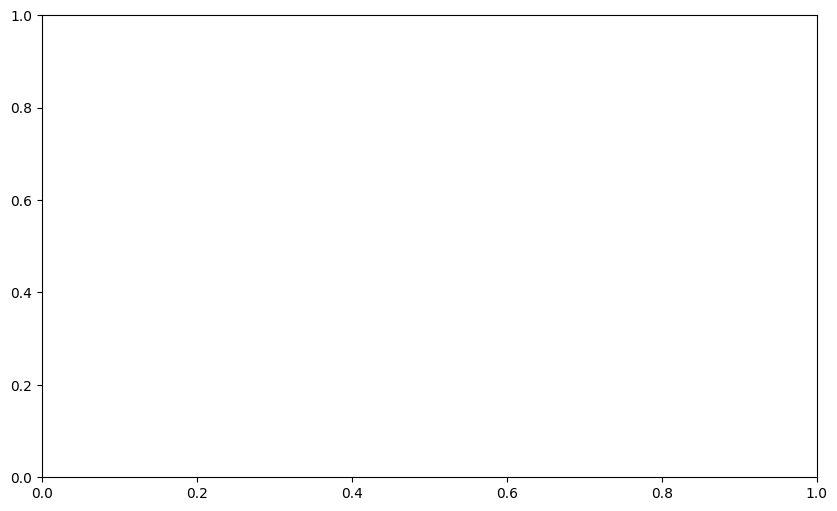

In [ ]:
# Now we can plot the train and validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_loss_history, label='Train Loss')
plt.plot(range(1, epochs+ 1), val_loss_history, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

# Assuming 'train_y' and 'train_prediction' are numpy arrays with shape (batch_size, sequence_length)

# Nash-Sutcliffe Efficiency (NSE) coefficient
nse_values = []
for i in range(train_y.shape[1]):  # Loop through each output sequence
    numerator = np.sum((train_y[:, i] - train_predictions[:, i]) ** 2)
    denominator = np.sum((train_y[:, i] - np.mean(train_y[:, i])) ** 2)
    nse = 1 - (numerator / denominator)
    nse_values.append(nse)
print("NSE:", nse_values)

# Evolution Criterion (Evol)
evol_values = []
for i in range(train_y.shape[1]):  # Loop through each output sequence
    numerator = np.sum(train_y[:, i])
    denominator = np.sum(train_predictions[:, i])
    evol = ((denominator - numerator) / numerator) * 100
    evol_values.append(evol)
print("Evol Criterion:", evol_values)

# Total Percent Error (TPE)
tpe_values = []
for i in range(train_y.shape[1]):  # Loop through each output sequence
    numerator = np.sum(np.abs(train_y[:, i] - train_predictions[:, i]))
    denominator = np.sum(train_y[:, i])
    tpe = numerator / denominator
    tpe_values.append(tpe)
print("TPE:", tpe_values)


NSE: [0.8718035969278519, 0.9161862679803913, 0.9443965864850383, 0.943956740137779, 0.9242297798646547]
Evol Criterion: [-10.651406877711903, -8.091794666723336, -5.655273487437089, 4.766695938153257, 8.462056281730028]
TPE: [0.2896696867242764, 0.23472739975067933, 0.18958031178761794, 0.18960144832230733, 0.2154782365648102]


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from numpy import array, hstack

# Prepare the test dataset
data_test = data.loc['2011-06-01':, :]
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_stacked_test = np.empty((data_test.shape[0], 0))

# Normalize and stack the test dataset
for column in data_test:
    x = data_test[column].values
    x = x.reshape((len(x), 1))
    x = scaler.fit_transform(x)
    dataset_stacked_test = hstack((dataset_stacked_test, x))

print("dataset_stacked_test.shape:", dataset_stacked_test.shape)

# Split the sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X_test, y_test = list(), list()
    for i in range(len(sequences) - n_steps_out):
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out - 1
        if out_end_ix > len(sequences) - n_steps_out:
            break
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix + 1, -1]
        X_test.append(seq_x)
        y_test.append(seq_y)
    return array(X_test), array(y_test)

# Example n_steps_in and n_steps_out values
n_steps_in = 30  # The number of previous time steps
n_steps_out =5  # The number of output time steps

X_test, y_test = split_sequences(dataset_stacked_test, n_steps_in, n_steps_out)
print("X_test.shape:", X_test.shape)
print("y_test.shape:", y_test.shape)

# Convert test data to PyTorch tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Move to device (if GPU is used)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

# Make sure the model is also on the device
model.to(device)

# Predict on test set
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_tensor).cpu().numpy()  # Detach predictions

# Calculate RMSE
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
print(f"Test Score: {test_rmse:.4f} RMSE")

# Calculate metrics (as arrays for all timesteps in `n_steps_out`)
nse_values = []
rsr_values = []
evol_values = []
tpe_values = []

for step in range(n_steps_out):
    observed = y_test[:, step]
    predicted = test_predictions[:, step]

    # Nash-Sutcliffe Efficiency (NSE)
    numerator = np.sum((observed - predicted) ** 2)
    denominator = np.sum((observed - np.mean(observed)) ** 2)
    nse = 1 - (numerator / denominator)
    nse_values.append(nse)

    # R-Squared Reliability (RSR)
    rsr = np.sqrt(numerator / denominator)
    rsr_values.append(rsr)

    # Evolution Criterion (Evol)
    evol = ((np.sum(predicted) - np.sum(observed)) / np.sum(observed)) * 100
    evol_values.append(evol)

    # Total Percent Error (TPE)
    numerator_tpe = np.sum(np.abs(observed - predicted))
    denominator_tpe = np.sum(observed)
    tpe = numerator_tpe / denominator_tpe
    tpe_values.append(tpe)

# Print metrics for all timesteps
print("NSE Values:", np.round(nse_values, 4))
print("RSR Values:", np.round(rsr_values, 4))
print("Evol Values:", np.round(evol_values, 4))
print("TPE Values:", np.round(tpe_values, 4))


dataset_stacked_test.shape: (488, 159)
X_test.shape: (450, 30, 159)
y_test.shape: (450, 5)
Test Score: 0.1124 RMSE
NSE Values: [0.2603 0.3596 0.307  0.1329 0.0058]
RSR Values: [0.86   0.8002 0.8325 0.9312 0.9971]
Evol Values: [-20.012  -21.8956 -22.9739  -2.5708   0.6101]
TPE Values: [0.7295 0.6983 0.7104 0.7775 0.8322]
